In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from deepeval.evaluate import EvaluationResult

In [2]:
def load_eval(file_path):
    with open(file_path, "rb") as f:
        result_obj = pickle.load(f)
    return result_obj

In [3]:
zero_iter_result_df_path = "../data/saved_data/zero_iter_result_df"
naive_rag_result_df_path = "../data/saved_data/naive_rag_result_df"
qrag_result_df_path      = "../data/saved_data/qrag_result_df"
df_test_path             = "../data/saved_data/df_test"         
df_test_paraphrase_path  = "../data/saved_data/df_test_paraphrase"


In [4]:
def eval_to_df(eval_result, label="qrag"):
    rows = []
    for test_case in eval_result.test_results:
        row = {
            "system_label": label,
            "case_name": test_case.name,
            "input": test_case.input,
            "success": test_case.success,
        }
        for metric_data in test_case.metrics_data:
            metric_name = metric_data.name
            row[f"{metric_name}_score"] = metric_data.score
        rows.append(row)
    import pandas as pd
    return pd.DataFrame(rows)


In [5]:
with open(df_test_path, "rb") as f:
    df_test = pickle.load(f)

with open(df_test_paraphrase_path, "rb") as f:
    df_test_paraphrase = pickle.load(f)

# Load evaluation results
naive_rag_eval_res = load_eval(naive_rag_result_df_path)
qrag_eval_res      = load_eval(qrag_result_df_path)

naive_rag_df = eval_to_df(naive_rag_eval_res, "naive_rag")
qrag_df      = eval_to_df(qrag_eval_res,      "qrag")

In [6]:
qrag_df.columns

Index(['system_label', 'case_name', 'input', 'success', 'Faithfulness_score',
       'Correctness (GEval)_score', 'Context Recall_score',
       'Context Precision_score'],
      dtype='object')

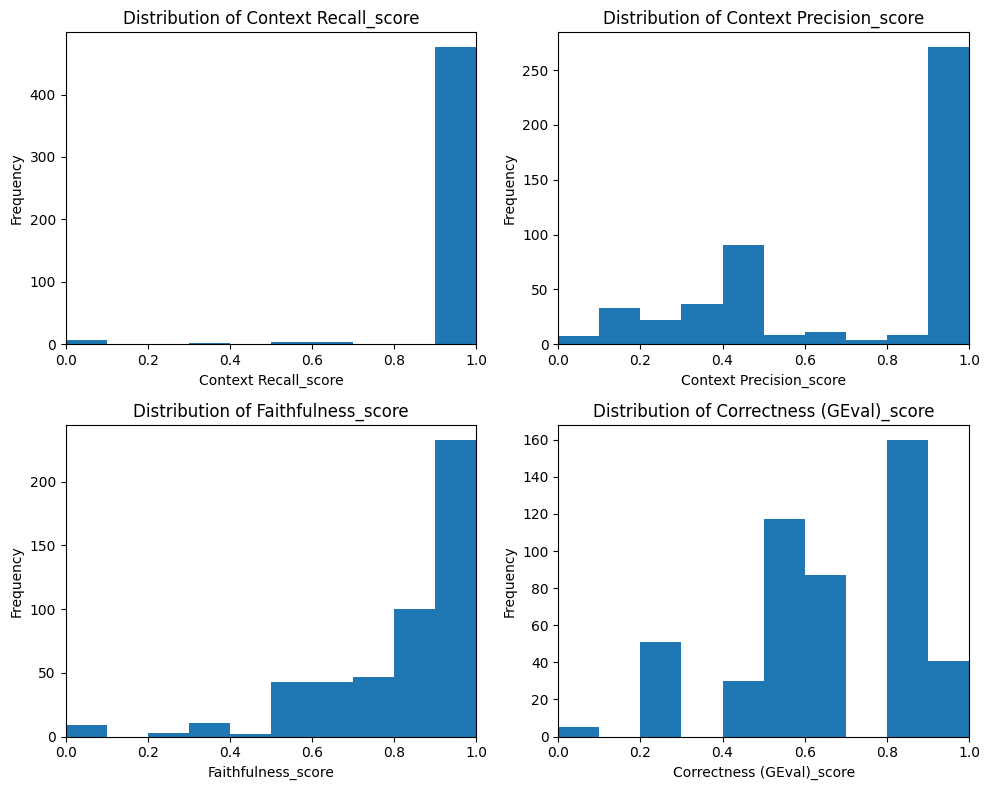

In [7]:
metric_columns = [
    "Context Recall_score",
    "Context Precision_score",
    "Faithfulness_score",
    "Correctness (GEval)_score"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, metric_col in enumerate(metric_columns):
    metric_data = qrag_df[metric_col].dropna()
    axes[i].hist(metric_data, bins=10)
    axes[i].set_xlim(0,1)
    axes[i].set_xlabel(metric_col)
    axes[i].set_ylabel("Frequency")
    axes[i].set_title(f"Distribution of {metric_col}")

plt.tight_layout()
plt.show()


Analyse the sub-category questions that this performs the best-worst

In [8]:
combined_df = pd.merge(
    qrag_df,
    df_test_paraphrase[["question", "question_type"]],
    left_on="input",
    right_on="question",
    how="left"
)
print(df_test_paraphrase["question_type"].value_counts())
print(combined_df["question_type"].value_counts())
grouped_qtype = combined_df.groupby("question_type")[metric_columns].mean()
print("Mean metrics by question_type:\n", grouped_qtype)

question_type
summarization     129
multi factual     128
yes/no            119
single factual    115
Name: count, dtype: int64
question_type
summarization     131
multi factual     129
yes/no            121
single factual    118
Name: count, dtype: int64
Mean metrics by question_type:
                 Context Recall_score  Context Precision_score  \
question_type                                                   
multi factual               0.971576                 0.740999   
single factual              0.983051                 0.741102   
summarization               0.977099                 0.765743   
yes/no                      0.983471                 0.697934   

                Faithfulness_score  Correctness (GEval)_score  
question_type                                                  
multi factual             0.821441                   0.670543  
single factual            0.836470                   0.736441  
summarization             0.852113                   0.629008  
y

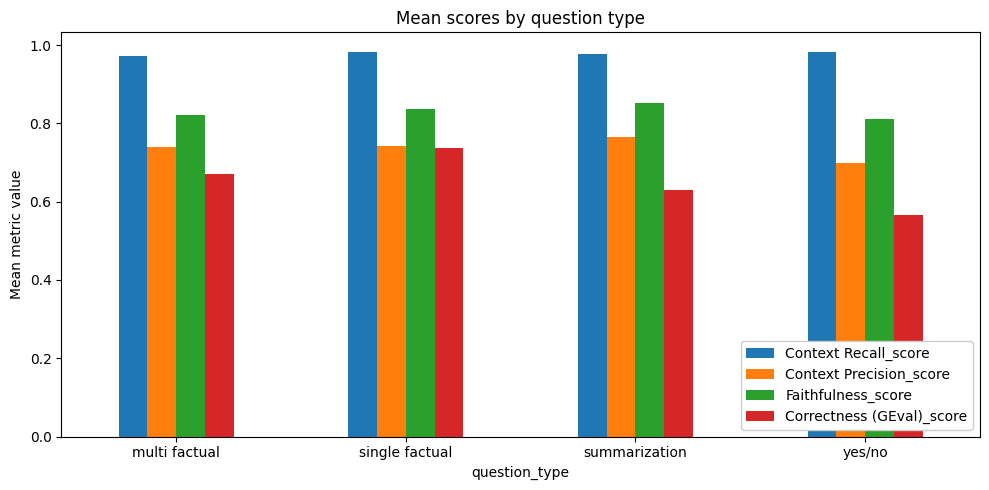

In [9]:
ax = grouped_qtype.plot(kind='bar', figsize=(10,5))
ax.set_title("Mean scores by question type")
ax.set_ylabel("Mean metric value")
ax.legend(loc='lower right', framealpha=1.0)

plt.xticks(rotation=0, ha='center')  
plt.tight_layout()
plt.show()

Check for outliers and low-score cases

In [10]:
def investigate_outliers(df, threshold=0.2, metric="Context Recall_score"):
    """
    Print Uthreshold-queries for the given metric to find the outlier or failing cases.
    """
    poor_cases = df[df[metric] < threshold].copy()
    poor_cases = poor_cases.sort_values(by=metric, ascending=True)

    print(f"\n=== 10 outlier Cases: {metric} < {threshold} ===")
    print(f"Total number of outliers: {len(poor_cases)}")
    # Show a few examples
    print(poor_cases[["case_name","input","question_type","syllabus_name",metric]].head(10))

    # You can do further grouping if you wish:
    if "question_type" in df.columns:
        grouping = poor_cases.groupby("question_type")[metric].count()
        print("\nOutlier distribution by question_type:")
        print(grouping)

df_naive_iter_merged = pd.merge(
    naive_rag_df,
    df_test_paraphrase[["id","question","question_type","syllabus_name"]],
    how="left",
    left_on="input",
    right_on="question"
)
df_qrag_merged = pd.merge(
    qrag_df,
    df_test_paraphrase[["id","question","question_type","syllabus_name"]],
    how="left",
    left_on="input",
    right_on="question"
)

investigate_outliers(df_naive_iter_merged, threshold=0.3, metric="Context Recall_score")
investigate_outliers(df_qrag_merged, threshold=0.3, metric="Context Recall_score")


=== 10 outlier Cases: Context Recall_score < 0.3 ===
Total number of outliers: 89
        case_name                                              input  \
20  test_case_118       What are the mandatory texts for this class?   
22  test_case_120    What academic level is this class intended for?   
27  test_case_125  \nDoes the class have multiple sessions per week?   
42  test_case_140         When does this class take place each week?   
43  test_case_141        Are specific hours designated for students?   
46  test_case_139  Which two websites or technology platforms are...   
68  test_case_158   When does the class take place and at what time?   
77  test_case_173                  When will the final exam be held?   
92  test_case_188  What are the anticipated activities for the st...   
95  test_case_184           How many tests are required to be taken?   

     question_type                      syllabus_name  Context Recall_score  
20   multi factual  MGMNT 462_ Syllabus - Spri

In [11]:
print(df_naive_iter_merged.columns)
print(df_qrag_merged.columns)

Index(['system_label', 'case_name', 'input', 'success', 'Faithfulness_score',
       'Correctness (GEval)_score', 'Context Recall_score',
       'Context Precision_score', 'id', 'question', 'question_type',
       'syllabus_name'],
      dtype='object')
Index(['system_label', 'case_name', 'input', 'success', 'Faithfulness_score',
       'Correctness (GEval)_score', 'Context Recall_score',
       'Context Precision_score', 'id', 'question', 'question_type',
       'syllabus_name'],
      dtype='object')


In [12]:
comp_df = pd.merge(
    df_naive_iter_merged,
    df_qrag_merged,
    on="id",
    suffixes=("_zero","_qrag")
)
print(comp_df.columns)

Index(['system_label_zero', 'case_name_zero', 'input_zero', 'success_zero',
       'Faithfulness_score_zero', 'Correctness (GEval)_score_zero',
       'Context Recall_score_zero', 'Context Precision_score_zero', 'id',
       'question_zero', 'question_type_zero', 'syllabus_name_zero',
       'system_label_qrag', 'case_name_qrag', 'input_qrag', 'success_qrag',
       'Faithfulness_score_qrag', 'Correctness (GEval)_score_qrag',
       'Context Recall_score_qrag', 'Context Precision_score_qrag',
       'question_qrag', 'question_type_qrag', 'syllabus_name_qrag'],
      dtype='object')


In [13]:
comp_df["CR_diff"] = comp_df["Context Recall_score_qrag"] - comp_df["Context Recall_score_zero"]
comp_df["CP_diff"] = comp_df["Context Precision_score_qrag"] - comp_df["Context Precision_score_zero"]
comp_df["FA_diff"] = comp_df["Faithfulness_score_qrag"] - comp_df["Faithfulness_score_zero"]
comp_df["AC_diff"] = comp_df["Correctness (GEval)_score_qrag"] - comp_df["Correctness (GEval)_score_zero"]

# Summarize improvements
print("\n=== Naive RAG vs Q-RAG Improvement Statistics ===")
print(comp_df[["CR_diff","CP_diff","FA_diff","AC_diff"]].describe())

improved_cases = comp_df[comp_df["CR_diff"] > 0.2]
print(f"\nNumber of queries with CR_diff > 0.2: {len(improved_cases)}")
print(improved_cases[["id","input_zero","Context Recall_score_zero","Context Recall_score_qrag","CR_diff"]].head(5))

# which question types or conditions lead to biggest improvement:
if "question_type_zero" in comp_df.columns:
    qtype_means = comp_df.groupby("question_type_zero")[["CR_diff","CP_diff","FA_diff","AC_diff"]].mean()
    print("\n=== Mean Metric Differences by question_type ===")
    print(qtype_means)


=== Naive RAG vs Q-RAG Improvement Statistics ===
          CR_diff     CP_diff     FA_diff     AC_diff
count  515.000000  515.000000  515.000000  515.000000
mean     0.194498    0.187443    0.002075    0.044272
std      0.378015    0.438399    0.248042    0.205331
min      0.000000   -0.750000   -1.000000   -0.600000
25%      0.000000    0.000000   -0.069048    0.000000
50%      0.000000    0.000000    0.000000    0.000000
75%      0.000000    0.500000    0.083333    0.100000
max      1.000000    1.000000    1.000000    0.900000

Number of queries with CR_diff > 0.2: 116
                  id                                         input_zero  \
6   jOReMIYockoT8qbl           What items should I bring for the class?   
8   2j9r7pQV4DRHupJn  What are the consequences of submitting all my...   
14  ZwGDck4QoMI6SSE3  Which components of this course are provided d...   
20  qEhU6OYMEMVdH5Q5       What are the mandatory texts for this class?   
22  uS5mQ6qocAZzFYYm    What academic level i

In [27]:
print(dir(zero_iter_eval_res.test_results[0].additional_metadata))

['__bool__', '__class__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__']


In [22]:
print(df_test['question_type'].unique())

['summarization' 'multi factual' 'yes/no' 'single factual']
